# DermaVision - Phase 1: Data Setup

This notebook downloads and prepares the HAM10000 skin lesion dataset.

**Dataset**: [Skin Cancer MNIST: HAM10000](https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000)

---

## 1. Install Dependencies

In [6]:
# Install dependencies if not already installed
%pip install -q kaggle pandas numpy matplotlib scikit-learn pillow tqdm tensorflow

Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


## 2. Kaggle API Setup

**Prerequisite**: You must have a Kaggle API token.
1. Go to https://www.kaggle.com/settings
2. Scroll to API section, click "Create New API Token"
3. Download `kaggle.json`
4. Place it in `C:\Users\<YourUser>\.kaggle\kaggle.json` (Windows) or `~/.kaggle/kaggle.json` (Linux/Mac).

Alternatively, you can set `KAGGLE_USERNAME` and `KAGGLE_KEY` environment variables.

In [5]:
import os
import json

In [ ]:


# Check if kaggle.json exists in default location
kaggle_path = os.path.expanduser('~/.kaggle/kaggle.json')

if os.path.exists(kaggle_path):
    print(f"Found kaggle.json at {kaggle_path}")
else:
    print("kaggle.json not found. Checking environment variables...")
    if 'KAGGLE_USERNAME' in os.environ and 'KAGGLE_KEY' in os.environ:
        print("Kaggle environment variables found.")
    else:
        print("WARNING: Kaggle credentials not found. Dataset download may fail.")
        print("Please place kaggle.json in ~/.kaggle/ or set KAGGLE_USERNAME and KAGGLE_KEY environment variables.")

kaggle.json not found. Checking environment variables...
Please place kaggle.json in ~/.kaggle/ or set KAGGLE_USERNAME and KAGGLE_KEY environment variables.


## 3. Download HAM10000 Dataset

In [6]:
# Download the dataset
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000

# Unzip it
import zipfile

if os.path.exists('skin-cancer-mnist-ham10000.zip'):
    with zipfile.ZipFile('skin-cancer-mnist-ham10000.zip', 'r') as zip_ref:
        zip_ref.extractall('ham10000_data')
    print("\nDone: Dataset downloaded and extracted!")
else:
    print("Dataset zip file not found. Did the download succeed?")

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
skin-cancer-mnist-ham10000.zip: Skipping, found more recently modified local copy (use --force to force download)

Done: Dataset downloaded and extracted!


In [7]:
# Check what we downloaded
if os.path.exists('ham10000_data'):
    print("ham10000_data directory exists.")
    print(os.listdir('ham10000_data')[:10])

ham10000_data directory exists.
['HAM10000_images_part_1', 'HAM10000_images_part_2', 'HAM10000_metadata.csv', 'hmnist_28_28_L.csv', 'hmnist_28_28_RGB.csv', 'hmnist_8_8_L.csv', 'hmnist_8_8_RGB.csv']


## 4. Load and Explore the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

# Load metadata
metadata_path = 'ham10000_data/HAM10000_metadata.csv'
if os.path.exists(metadata_path):
    metadata = pd.read_csv(metadata_path)
    print(f"Total images in dataset: {len(metadata)}")
    print(f"\nColumns: {list(metadata.columns)}")
    print(f"\nClass distribution:")
    print(metadata['dx'].value_counts())
else:
    print("Metadata file not found! Check dataset download.")

Total images in dataset: 10015

Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


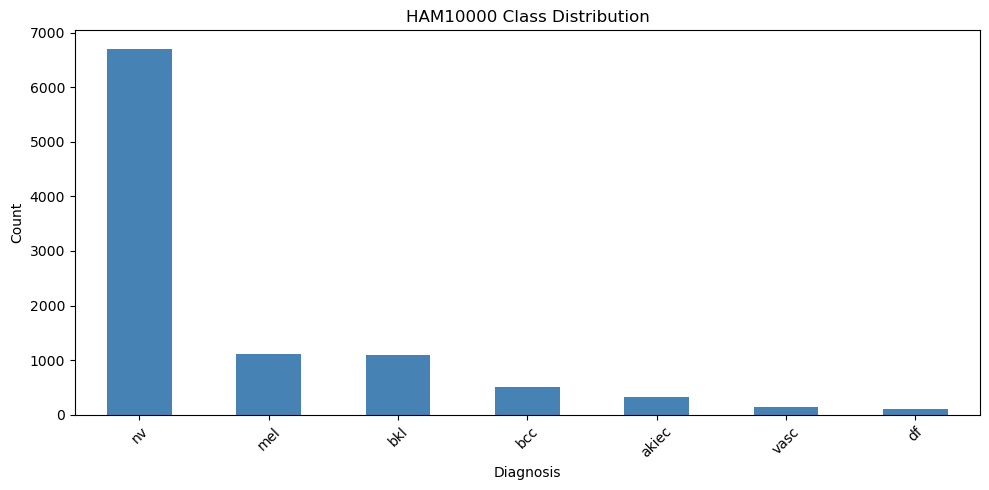


Saved class_distribution.png


In [2]:
# Show class distribution as bar chart
if 'metadata' in locals():
    plt.figure(figsize=(10, 5))
    metadata['dx'].value_counts().plot(kind='bar', color='steelblue')
    plt.title('HAM10000 Class Distribution')
    plt.xlabel('Diagnosis')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('class_distribution.png', dpi=100)
    plt.show()
    print("\nSaved class_distribution.png")

## 5. Simplify to 4 Classes

For this project, we use 4 classes:
- **melanoma** (mel) - Malignant skin cancer
- **nevus** (nv) - Benign mole (most common)
- **other** - Combined remaining skin classes
- **invalid** - Non-skin images (from CIFAR-10)

In [3]:
# Map skin lesion classes to 3 labels (invalid loaded separately)
def simplify_class(dx):
    if dx == 'mel':
        return 'melanoma'
    elif dx == 'nv':
        return 'nevus'
    else:
        return 'other'

if 'metadata' in locals():
    metadata['class'] = metadata['dx'].apply(simplify_class)
    print("Simplified class distribution (skin lesions only):")
    print(metadata['class'].value_counts())

Simplified class distribution (skin lesions only):
class
nevus       6705
other       2197
melanoma    1113
Name: count, dtype: int64


## 6. Create Balanced Subset (4000 images)

We take 1000 images per class for faster training.
The 4th class (invalid) is loaded separately from ham10000_data/invalid/.

In [4]:
# Create balanced subset for skin lesion classes
import glob
SAMPLES_PER_CLASS = 1000
INVALID_DIR = 'ham10000_data/invalid'

if 'metadata' in locals():
    subset_dfs = []
    for class_name in ['melanoma', 'nevus', 'other']:
        class_df = metadata[metadata['class'] == class_name]
        # Sample with replacement if class is smaller than needed
        if len(class_df) >= SAMPLES_PER_CLASS:
            sampled = class_df.sample(n=SAMPLES_PER_CLASS, random_state=42)
        else:
            sampled = class_df.sample(n=SAMPLES_PER_CLASS, replace=True, random_state=42)
        subset_dfs.append(sampled)

    subset = pd.concat(subset_dfs, ignore_index=True)
    subset = subset.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle

    # Load invalid image paths
    invalid_paths = glob.glob(f'{INVALID_DIR}/*.jpg')
    invalid_paths = invalid_paths[:SAMPLES_PER_CLASS]
    print(f"Found {len(invalid_paths)} invalid images in {INVALID_DIR}")

    print(f"Skin lesion subset size: {len(subset)}")
    print(f"Total images (skin + invalid): {len(subset) + len(invalid_paths)}")
    print(f"\nSkin lesion class distribution:")
    print(subset['class'].value_counts())

Found 1000 invalid images in ham10000_data/invalid
Skin lesion subset size: 3000
Total images (skin + invalid): 4000

Skin lesion class distribution:
class
nevus       1000
melanoma    1000
other       1000
Name: count, dtype: int64


## 7. Load and Preprocess Images

In [7]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tqdm import tqdm

IMG_SIZE = 128

def find_image_path(image_id):
    """Find image in either part1 or part2 folder."""
    for folder in ['HAM10000_images_part_1', 'HAM10000_images_part_2']:
        path = f'ham10000_data/{folder}/{image_id}.jpg'
        if os.path.exists(path):
            return path
    return None

def load_and_preprocess(image_id):
    """Load and preprocess a single image."""
    path = find_image_path(image_id)
    if path is None:
        return None
    img = load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img) / 255.0  # Normalize to [0, 1]
    return img_array

# ── Load skin lesion images ──────────────────────────────────────────
if 'subset' in locals():
    print("Loading and preprocessing skin lesion images...")
    images = []
    labels = []
    valid_indices = []

    for idx, row in tqdm(subset.iterrows(), total=len(subset)):
        img = load_and_preprocess(row['image_id'])
        if img is not None:
            images.append(img)
            labels.append(row['class'])
            valid_indices.append(idx)

    # ── Load invalid images ──────────────────────────────────────────
    print(f"\nLoading {len(invalid_paths)} invalid images...")
    for path in tqdm(invalid_paths):
        try:
            img = load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
            img_array = img_to_array(img) / 255.0
            images.append(img_array)
            labels.append('invalid')
        except Exception as e:
            print(f"Skipping {path}: {e}")

    X = np.array(images)
    print(f"\nDone: Loaded {len(X)} images total (skin + invalid)")
    print(f"Shape: {X.shape}")

Loading and preprocessing skin lesion images...


100%|██████████| 3000/3000 [01:06<00:00, 45.38it/s]



Loading 1000 invalid images...


100%|██████████| 1000/1000 [00:03<00:00, 255.89it/s]



Done: Loaded 4000 images total (skin + invalid)
Shape: (4000, 128, 128, 3)


In [8]:
# Convert labels to numbers
# NOTE: LabelEncoder sorts alphabetically:
#   0=invalid, 1=melanoma, 2=nevus, 3=other
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

if 'labels' in locals():
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(labels)
    y = to_categorical(y_encoded, num_classes=4)

    print(f"Label classes: {label_encoder.classes_}")
    print(f"y shape: {y.shape}")

Label classes: ['invalid' 'melanoma' 'nevus' 'other']
y shape: (4000, 4)


## 8. Split into Train/Validation/Test

In [9]:
from sklearn.model_selection import train_test_split

if 'X' in locals() and 'y' in locals():
    # First split: 70% train, 30% temp
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # Second split: 50% validation, 50% test (from temp)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
    )

    print(f"Training set:   {X_train.shape[0]} images")
    print(f"Validation set: {X_val.shape[0]} images")
    print(f"Test set:       {X_test.shape[0]} images")

Training set:   2800 images
Validation set: 600 images
Test set:       600 images


## 9. Visualize Sample Images

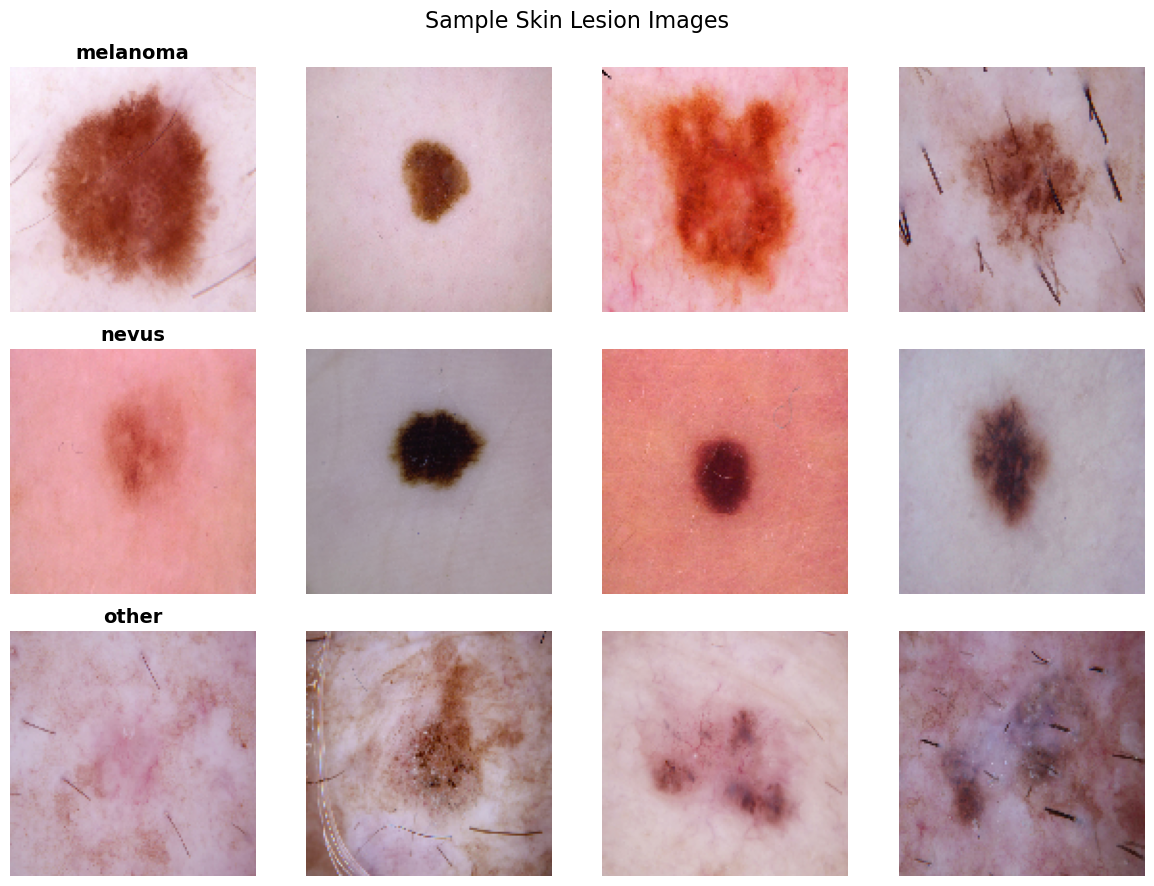


Saved sample_images.png


In [10]:
# Show some sample images
if 'X_train' in locals():
    fig, axes = plt.subplots(3, 4, figsize=(12, 9))

    for i, class_name in enumerate(['melanoma', 'nevus', 'other']):
        class_idx = list(label_encoder.classes_).index(class_name)
        class_images = X_train[np.argmax(y_train, axis=1) == class_idx][:4]
        
        for j, img in enumerate(class_images):
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(class_name, fontsize=14, fontweight='bold')

    plt.suptitle('Sample Skin Lesion Images', fontsize=16)
    plt.tight_layout()
    plt.savefig('sample_images.png', dpi=100)
    plt.show()

    print("\nSaved sample_images.png")

## 10. Save Processed Data (Local)

In [11]:
# Save to numpy files for later use
if 'X_train' in locals():
    np.save('X_train.npy', X_train)
    np.save('X_val.npy', X_val)
    np.save('X_test.npy', X_test)
    np.save('y_train.npy', y_train)
    np.save('y_val.npy', y_val)
    np.save('y_test.npy', y_test)

    # Save label encoder classes
    np.save('label_classes.npy', label_encoder.classes_)

    print("Done: Data saved to .npy files!")
    print("\nFiles created:")
    import glob
    print(glob.glob("*.npy"))

Done: Data saved to .npy files!

Files created:
['label_classes.npy', 'X_test.npy', 'X_train.npy', 'X_val.npy', 'y_test.npy', 'y_train.npy', 'y_val.npy']


## 11. Backup Data

This copies your data to a backup folder. You can point this to your Google Drive Desktop folder to sync with the cloud.

In [17]:
import shutil

# Configure Backup Directory
# Point this to your Google Drive or any other backup location
BACKUP_DIR = 'backup/DermaVision' 

os.makedirs(BACKUP_DIR, exist_ok=True)

print(f"Backing up data to {BACKUP_DIR}...")

# Copy files
files_to_backup = glob.glob("*.npy") + glob.glob("*.png")

for file in files_to_backup:
    try:
        shutil.copy2(file, BACKUP_DIR)
        print(f"Backed up: {file}")
    except Exception as e:
        print(f"Error backing up {file}: {e}")

print("\nDone: Data backed up!")

Backing up data to backup/DermaVision...
Backed up: label_classes.npy
Backed up: X_test.npy
Backed up: X_train.npy
Backed up: X_val.npy
Backed up: y_test.npy
Backed up: y_train.npy
Backed up: y_val.npy
Backed up: class_distribution.png
Backed up: sample_images.png

Done: Data backed up!


---

## Phase 1 Complete

**Summary**:
- Downloaded HAM10000 dataset
- Simplified to 3 classes: melanoma, nevus, other
- Created balanced subset of 3,000 images
- Preprocessed images to 128x128 and normalized
- Split into train/val/test sets (70/15/15)
- Backed up to local backup directory

**Next**: Run `02_BaselineCNN.ipynb` to train the baseline model.